In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications 
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models



# Path to the dataset
data_dir = '/content/drive/MyDrive/Brain_Data_Organised'
normal_dir = os.path.join(data_dir, 'normal')
stroke_dir = os.path.join(data_dir, 'stroke')

# Load the dataset
image_size = (224, 224)  # Resize all images to 224x224
batch_size = 32


In [16]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

train_dataset = image_dataset_from_directory(
    data_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary',  # 0 for normal, 1 for stroke
    subset="training",  # You can split the dataset into training and validation sets
    validation_split=0.2,  # 80% training, 20% validation
    seed=42
)

validation_dataset = image_dataset_from_directory(
    data_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary',
    subset="validation",
    validation_split=0.2,
    seed=42
)


Found 2501 files belonging to 2 classes.
Using 2001 files for training.
Found 2501 files belonging to 2 classes.
Using 500 files for validation.


In [17]:
# Load the dataset
image_size = (224, 224)  # Resize all images to 224x224
batch_size = 32

train_dataset = image_dataset_from_directory(
    data_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary',  # 0 for normal, 1 for stroke
    subset="training",  # You can split the dataset into training and validation sets
    validation_split=0.2,  # 80% training, 20% validation
    seed=42
)

validation_dataset = image_dataset_from_directory(
    data_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='binary',
    subset="validation",
    validation_split=0.2,
    seed=42
)


Found 2501 files belonging to 2 classes.
Using 2001 files for training.
Found 2501 files belonging to 2 classes.
Using 500 files for validation.


In [18]:
# Normalize the image data
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))


In [19]:
def build_model(input_shape=(224, 224, 3)):
    model = models.Sequential()

    # Convolutional layers
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten the feature map
    model.add(layers.Flatten())

    # Fully connected layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))  # Binary output (normal or stroke)

    # Compile the model
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model


In [24]:
model = build_model()

# Train the model
epochs = 10  # You can adjust this depending on your dataset

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 383s 6s/step - accuracy: 0.5590 - loss: 0.9896 - val_accuracy: 0.6600 - val_loss: 0.6106
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 0.6877 - loss: 0.5731 - val_accuracy: 0.8000 - val_loss: 0.4148
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.8215 - loss: 0.3754 - val_accuracy: 0.9020 - val_loss: 0.2385
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 283s 4s/step - accuracy: 0.9166 - loss: 0.2055 - val_accuracy: 0.9200 - val_loss: 0.1756
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 261s 4s/step - accuracy: 0.9478 - loss: 0.1348 - val_accuracy: 0.9460 - val_loss: 0.1201
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 258s 4s/step - accuracy: 0.9600 - loss: 0.0950 - val_accuracy: 0.9620 - val_loss: 0.1146
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.9762 - loss: 0.0616 - val_accuracy: 0.9520 - val_loss: 0.0972
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 312s 4s/step - accuracy: 0.9846 - loss: 0.0420 - val_accuracy: 0.9640 - v

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9726 - loss: 0.0711
Test accuracy: 0.9700000286102295


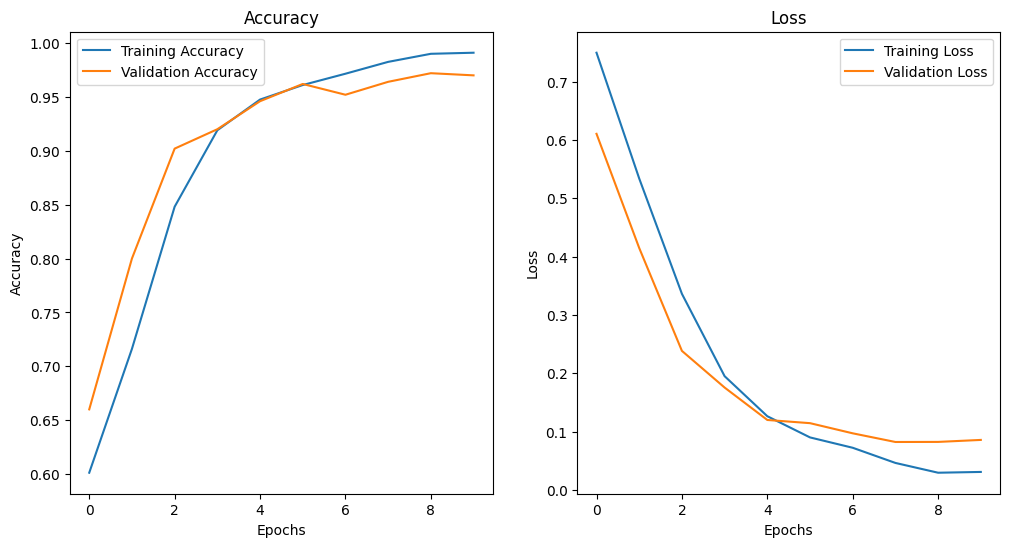

In [25]:
# Evaluate the model on the validation data
test_loss, test_acc = model.evaluate(validation_dataset)
print(f"Test accuracy: {test_acc}")

# Plot the training and validation accuracy/loss
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [26]:
model.save('/content/drive/MyDrive/brainstroke_model.h5')


In [30]:
def predict_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # Create batch dimension

    prediction = model.predict(img_array)
    if prediction < 0.5:
        return "Normal"
    else:
        return "Stroke"

# Example usage
image_path = '/content/drive/MyDrive/Brain_Data_Organised/Stroke/58 (2).jpg'  # Update with your image path
result = predict_image(image_path)
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Stroke
